## __Regularization__

**Regularization in Regression**

Regularization encompasses a set of techniques employed to address the issue of overfitting.

**Core Concept**

Regularization techniques achieve their objective by introducing a penalty term to the model's objective function. This objective function, typically measured by mean squared error, is minimized during the training process. The penalty term discourages the model from attaining excessive complexity by penalizing the size of the model coefficients, thereby mitigating overfitting.

**Regularization term** or `alpha`: is a hyperparameter that scales the penalty term. It controls the strength of regularization.
- Higher `alpha`: Imposes a stronger penalty on the coefficients, leading to greater regularization. This tends to produce a simpler model that may underfit the training data but often generalizes better to unseen data.
- Lower `alpha`: Imposes a weaker penalty, leading to a model that is less restricted by the regularization and more complex, potentially capturing more details in the data but at the risk of overfitting.

**Benefits of Regularization**

Enhanced Generalizability: By mitigating overfitting, regularization fosters models that perform well on unseen data.

Reduced Model Complexity: It promotes interpretability and potentially reduces computational costs associated with training complex models.


Common Regularization Techniques are:

* Lasso Regression (L1 Regularization)
* Ridge Regression (L2 Regularization)


### __Least Absolute Shrinkage and Selection Operator (Lasso) Regression__

**Least Absolute Shrinkage and Selection Operator (Lasso) Regression** relies upon the linear regression model but additionaly performs a so called L1 regularization, which is a process of introducing additional information in order to prevent overfitting. As a consequence, we can fit a model containing all possible predictors and use lasso to perform variable selection by using a technique that regularizes the coefficient estimates (it shrinks the coefficient estimates towards zero).

- It performs variable selection or feature selection.
- It forces some of the coeﬃcient estimates to be exactly equal to zero with the help of a large tuning parameter λ.
- It helps reduce the learning of more complex data and overfitting of the model.
- It decreases the variance of the model without an increase in bias.
  
In particular, the minimization objective does not only include the residual sum of squares (RSS) - like in the OLS regression setting - but also the sum of the absolute value of coefficients.

**Residual Sum of Squares (RSS)**, which is the sum of square of difference between actual and predicted values.

$$ \text{RSS} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Where:

$y_i$: represents the actual target value from the dataset

​$\hat{y}_i$: represents the predicted target values by the regression model.

𝑛: is the number of observations.


The predictions ​$\hat{y}_i$ in a regression model are typically calculated using the linear regression equation. For multiple regression involving several predictor variable, the equation is:


 $ \hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \ldots + \beta_nx_ n $ predictor.


- $ x_1, x_2, \ldots, x_n $ are the predictor variables,
- $ \beta_1, \beta_2, \ldots, \beta_n $ are the coefficients for each predictor.

The RSS formula for multiple linear regression can also be written as:

$$ \text{RSS} = \sum_{i=1}^n \left( y_i - \left( \beta_0 + \sum_{j=1}^p \beta_j x_{ij} \right) \right)^2 $$

Where:

- $ y_i $ represents the actual value for the \(i\)-th observation.
- $ \beta_0 \ $ is the intercept.
- $ \beta_j \ $ are the coefficients for each predictor \(j\).
- $ x_{ij} $ represents the \(j\)-th predictor variable for the \(i\)-th observation.
- $ n $ is the total number of observations.
- $ p $ is the number of predictor variables.

In Lasso regression, the minimization objective becomes:

$$ \sum_{i=1}^n \left( y_i - \left( \beta_0 + \sum_{j=1}^p \beta_j x_{ij} \right) \right)^2 + \alpha \sum_{j=1}^p |\beta_j| $$

which equals:

$$ \text{RSS} + \alpha \sum_{j=1}^p |\beta_j| $$

Where $ \alpha \ $ (alpha) can take various values:
- $ \alpha = 0 \ $: Same coefficients as least squares linear regression
- $ \alpha = \infty $: All coefficients are zero
- $ 0 < \alpha < \infty $: Coefficients are between 0 and that of least squares linear regression


### Now, Let us implement lasso regression.

In [32]:
# Import necessary libraries
import numpy as np
import pandas as pd
pd.options.display.max_columns = 300

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso , LassoCV

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

**Description of the Dataset**

A data frame with 263 observations of major league players on the following 20 variables (see more about the dataset in this [documentation](https://cran.r-project.org/web/packages/ISLR/ISLR.pdf))




**We want to predict a baseball player's salary based on various statistics associated with performance in the previous year.**


In [69]:
# Load the data from a CSV file into a DataFrame and display 5 rows
df = pd.read_csv('Hitters.csv')
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
1,-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
2,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
3,-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
4,-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


In [70]:
df.columns

Index(['Unnamed: 0', 'AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years',
       'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League',
       'Division', 'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='str')

In [71]:
# Remove "Unnamed: 0" from the dataframe
df.drop('Unnamed: 0', axis = 1, inplace = True)

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    str    
 14  Division   263 non-null    str    
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    str    
dtypes: float64(1), int64(

**Observations**
- Overall, it includes 263 observations and 20 columns.

In [73]:
print("Number of missing values in 'Salary':", len(df[df['Salary'].isnull()]))

Number of missing values in 'Salary': 0


Since we will use the lasso algorithm from scikit learn, we need to encode our categorical features as one-hot numeric features (dummy variables):

**Note: Lasso regression assumes that the features are numeric and continuous, and does not work well with categorical variables.**

In [12]:
pd.get_dummies(data = df , columns = ['League', 'Division','NewLeague'] , drop_first = True)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
1,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
2,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
3,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
4,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,497,127,7,65,48,37,5,2703,806,32,379,311,138,325,9,3,700.0,True,False,True
259,492,136,5,76,50,94,12,5511,1511,39,897,451,875,313,381,20,875.0,False,False,False
260,475,126,3,61,43,52,6,1700,433,7,217,93,146,37,113,7,385.0,False,True,False
261,573,144,9,85,60,78,8,3198,857,97,470,420,332,1314,131,12,960.0,False,False,False


Creating dummy variables for `League`, `Division`, and `NewLeague` allows us to convert categorical data into a numerical format suitable for machine learning models, while avoiding multicollinearity by dropping one category. This ensures that the models can interpret and leverage these categorical distinctions effectively.

**Data Description**
* **League (A or N):** American League (A) or National League (N) as of the end of 1986.
* **Division (E or W):** Eastern Division (E) or Western Division (W) as of the end of 1986.
* **NewLeague (A or N):** American League (A) or National League (N) as of the beginning of 1987.

`League_N`: 1 if the league is National League (N), 0 otherwise.

`Division_W`: 1 if the division is Western Division (W), 0 otherwise.

`NewLeague_N`: 1 if the new league is National League (N), 0 otherwise.

In [13]:
# creating dummies for all the variable of object type
df = pd.get_dummies(data = df , columns = ['League', 'Division','NewLeague'] , drop_first = True)

<class 'pandas.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        263 non-null    int64  
 1   Hits         263 non-null    int64  
 2   HmRun        263 non-null    int64  
 3   Runs         263 non-null    int64  
 4   RBI          263 non-null    int64  
 5   Walks        263 non-null    int64  
 6   Years        263 non-null    int64  
 7   CAtBat       263 non-null    int64  
 8   CHits        263 non-null    int64  
 9   CHmRun       263 non-null    int64  
 10  CRuns        263 non-null    int64  
 11  CRBI         263 non-null    int64  
 12  CWalks       263 non-null    int64  
 13  PutOuts      263 non-null    int64  
 14  Assists      263 non-null    int64  
 15  Errors       263 non-null    int64  
 16  Salary       263 non-null    float64
 17  League_N     263 non-null    bool   
 18  Division_W   263 non-null    bool   
 19  NewLeague_N  263 no

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AtBat    263 non-null    int64  
 1   Hits     263 non-null    int64  
 2   HmRun    263 non-null    int64  
 3   Runs     263 non-null    int64  
 4   RBI      263 non-null    int64  
 5   Walks    263 non-null    int64  
 6   Years    263 non-null    int64  
 7   CAtBat   263 non-null    int64  
 8   CHits    263 non-null    int64  
 9   CHmRun   263 non-null    int64  
 10  CRuns    263 non-null    int64  
 11  CRBI     263 non-null    int64  
 12  CWalks   263 non-null    int64  
 13  PutOuts  263 non-null    int64  
 14  Assists  263 non-null    int64  
 15  Errors   263 non-null    int64  
 16  Salary   263 non-null    float64
dtypes: float64(1), int64(16)
memory usage: 35.1 KB


In [94]:
corr = df.corr()
corr[((corr > 0.4) | (corr < -0.4)) & (corr != 1)].fillna('')

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,,0.963969,0.555102,0.899829,0.796015,0.624448,,,,,,,,,,,
Hits,0.963969,,0.530627,0.91063,0.788478,0.587311,,,,,,,,,,,0.438675
HmRun,0.555102,0.530627,,0.631076,0.849107,0.440454,,,,0.492526,,,,,,,
Runs,0.899829,0.91063,0.631076,,0.778692,0.697015,,,,,,,,,,,0.419859
RBI,0.796015,0.788478,0.849107,0.778692,,0.569505,,,,0.44219,,,,,,,0.449457
Walks,0.624448,0.587311,0.440454,0.697015,0.569505,,,,,,,,0.42914,,,,0.443867
Years,,,,,,,,0.915681,0.897844,0.722371,0.876649,0.863809,0.837524,,,,0.400657
CAtBat,,,,,,,0.915681,,0.995057,0.801676,0.982747,0.95073,0.906712,,,,0.526135
CHits,,,,,,,0.897844,0.995057,,0.786652,0.984542,0.946797,0.890718,,,,0.54891
CHmRun,,,0.492526,,0.44219,,0.722371,0.801676,0.786652,,0.825625,0.927903,0.810878,,,,0.524931


In [78]:
# create label X and y
y = df['Salary']

# drop the column with the outcome variable (Salary), and categorical columns for which dummy variables is already created:
x = df.drop(['Salary'], axis = 1).astype('float64')
x_cols =  x.columns

x.info()

<class 'pandas.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AtBat    263 non-null    float64
 1   Hits     263 non-null    float64
 2   HmRun    263 non-null    float64
 3   Runs     263 non-null    float64
 4   RBI      263 non-null    float64
 5   Walks    263 non-null    float64
 6   Years    263 non-null    float64
 7   CAtBat   263 non-null    float64
 8   CHits    263 non-null    float64
 9   CHmRun   263 non-null    float64
 10  CRuns    263 non-null    float64
 11  CRBI     263 non-null    float64
 12  CWalks   263 non-null    float64
 13  PutOuts  263 non-null    float64
 14  Assists  263 non-null    float64
 15  Errors   263 non-null    float64
dtypes: float64(16)
memory usage: 33.0 KB


In [79]:
# Split the dataset into training and testing sets before handling missing values
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

**Data leakage** ----------------------

In [80]:
X_train

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
180,547.0,137.0,2.0,58.0,47.0,12.0,2.0,1038.0,271.0,3.0,129.0,80.0,24.0,261.0,459.0,22.0
175,299.0,75.0,6.0,38.0,23.0,26.0,3.0,580.0,160.0,8.0,71.0,33.0,44.0,212.0,1.0,2.0
97,584.0,158.0,15.0,70.0,84.0,42.0,5.0,2358.0,636.0,58.0,265.0,316.0,134.0,331.0,20.0,4.0
177,381.0,110.0,9.0,61.0,45.0,32.0,7.0,3015.0,834.0,40.0,451.0,249.0,168.0,228.0,7.0,5.0
60,255.0,70.0,7.0,49.0,35.0,43.0,15.0,6311.0,1661.0,154.0,1019.0,608.0,820.0,51.0,54.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,629.0,168.0,18.0,73.0,102.0,40.0,18.0,8424.0,2464.0,164.0,1008.0,1072.0,402.0,1067.0,157.0,14.0
188,237.0,52.0,0.0,15.0,25.0,30.0,24.0,14053.0,4256.0,160.0,2165.0,1314.0,1566.0,523.0,43.0,6.0
71,511.0,138.0,25.0,76.0,96.0,61.0,3.0,592.0,164.0,28.0,87.0,110.0,71.0,157.0,7.0,8.0
106,343.0,103.0,6.0,48.0,36.0,40.0,15.0,4338.0,1193.0,70.0,581.0,421.0,325.0,211.0,56.0,13.0


### Create a Lasso Model.

First, we apply lasso regression on the training set with regularization parameter `alpha`=1

`alpha = 1`: This value is commonly used as default and provides a good balance between maintaining model complexity and reducing overfitting.


In [81]:
# Create and fit the Lasso regression model to the training data
lasso_model = Lasso( alpha = 1 , max_iter = 10000)
lasso_model.fit(X_train, y_train)
print("Lasso intercept:", lasso_model.intercept_)

# Get the coefficients (weights) of the fitted Lasso regression model
pd.DataFrame(data = {'x_var' : x_cols , 'coef' : lasso_model.coef_.round(2)})

Lasso intercept: 6.584476784142339


,x_var,coef
0,AtBat,-1.73
1,Hits,7.80
2,HmRun,2.22
3,Runs,-2.71
4,RBI,-0.25
5,Walks,5.50
6,Years,5.12
7,CAtBat,-0.21
8,CHits,-0.10
9,CHmRun,-0.95


**Observation**

This is the intercept term of your Lasso regression model. It represents the expected mean value of the dependent variable when all independent variables are set to zero. In practical terms, it's the baseline prediction when no other information (from the variables) is provided.

* Lasso coefficients: represent the relationship between each independent variable and the dependent variable.
Each coefficient estimates the change in the dependent variable for a one unit change in the respective independent variable, holding all other variables constant.
    - A positive coefficient indicates that as the independent variable increases, the dependent variable also increases.
    - A negative coefficient indicates that as the independent variable increases, the dependent variable decreases.
    - The magnitude of the coefficient shows the strength of the impact. A larger absolute value indicates a stronger effect.




* Lasso regression is known for its ability to perform feature selection by shrinking some coefficients to zero, thus effectively removing those variables from the equation.

**Model Evaluation on Lasso model**

In [83]:
# Training data
pred_train = lasso_model.predict(X_train)
mape_train = mean_absolute_percentage_error(y_train, pred_train)
print('MAPE training set', round(mape_train, 2))
print('R squared training set', round(r2_score(y_train, pred_train),2))

print("---------------------------")

# Test data
pred_test = lasso_model.predict(X_test)
mape_test = mean_absolute_percentage_error(y_test, pred_test)
print('MAPE test set', round(mape_test, 2))
print('R squared test set', round(r2_score(y_test, pred_test),2))

MAPE training set 0.71
R squared training set 0.57
---------------------------
MAPE test set 0.6
R squared test set 0.29


To better understand the role of `alpha`(regularization parameter), plot the lasso coefficients as a function of `alpha` (max_iter are the maximum number of iterations):

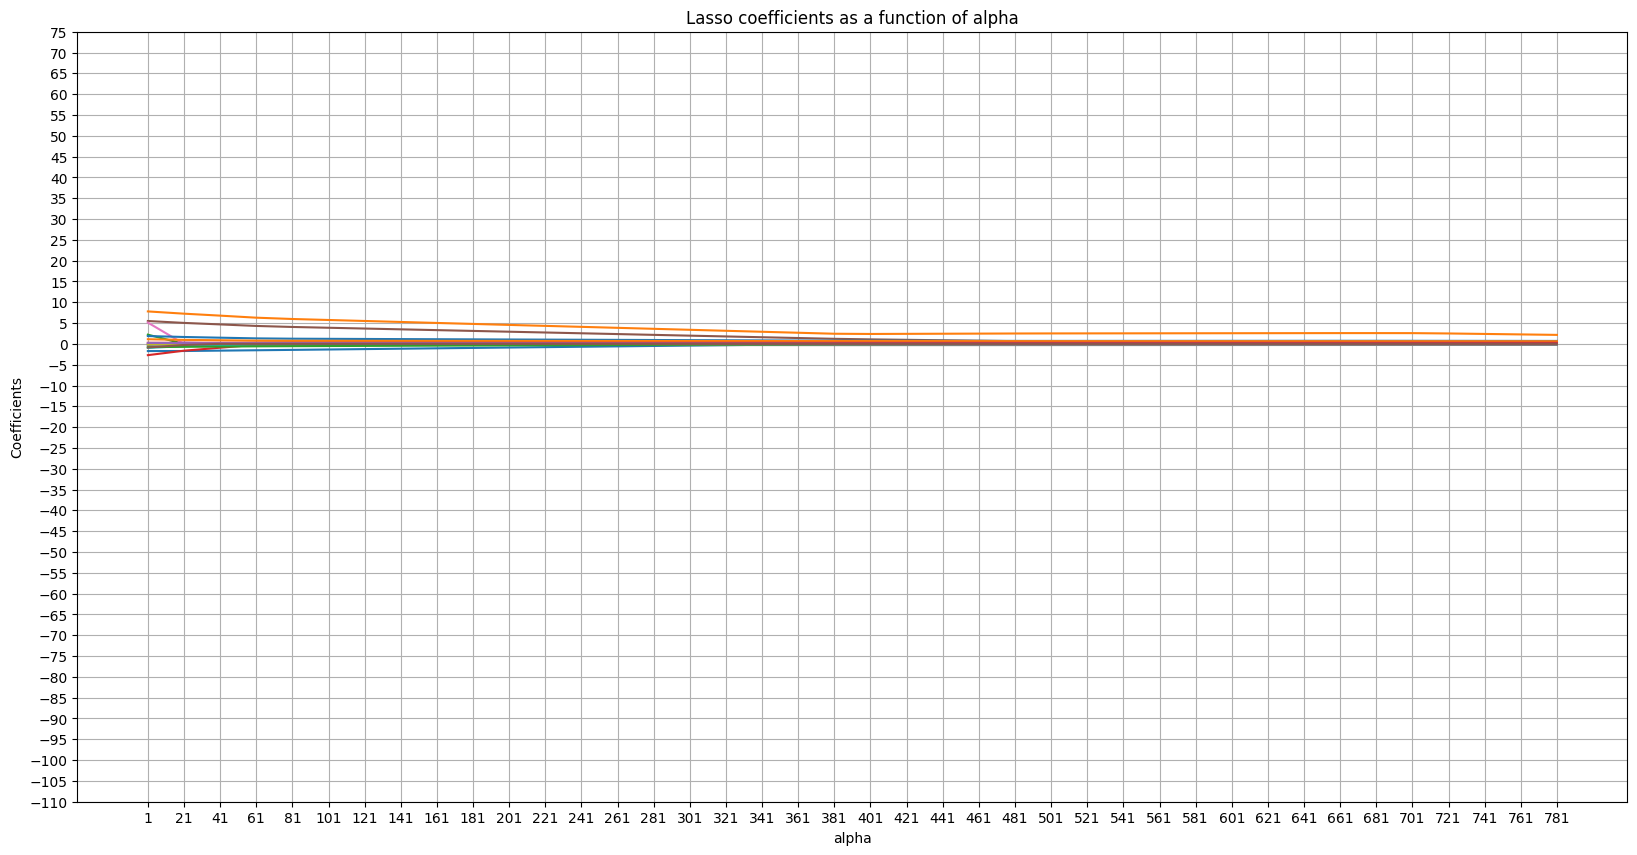

In [84]:
alphas = range(1,800,20)
coefs = []

for a in alphas:
    lasso = Lasso(alpha = a, max_iter = 10000)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)


fig = plt.figure(figsize = (20, 10))
plt.grid(True)
plt.plot(alphas, coefs)

plt.xlabel('alpha')
plt.xticks(alphas)

plt.ylabel('Coefficients')
plt.yticks(range(-110, 80 , 5))

plt.title('Lasso coefficients as a function of alpha')
plt.show()

Moving from left to right in the plot, observe that at first the lasso models contains many predictors with high magnitudes of coefficient estimates. With increasing `alpha`, the coefficient estimates approximate towards zero.

In [85]:
from tqdm import tqdm

# Create and fit the lasso with multiple alpha values
alphas = range(1,800,2)
mape = {}

for a in tqdm(alphas):
    lasso = Lasso(alpha = a, max_iter = 10000)
    lasso.fit(X_train, y_train)
    mape_train = mean_absolute_percentage_error(y_train, lasso.predict(X_train))
    mape_test = mean_absolute_percentage_error(y_test, lasso.predict(X_test))
    r2_test = r2_score(y_test, lasso.predict(X_test))
    mape[a] = [mape_train , mape_test , (mape_train + mape_test) / 2, r2_test]

100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:06<00:00, 63.60it/s]


In [86]:
alpha_mape = pd.DataFrame(index = mape.keys() , data = mape.values() , columns = ['mape_train', 'mape_test', 'avg_mape', 'r2_test'])
alpha_mape.sort_values('r2_test', ascending = False)

,mape_train,mape_test,avg_mape,r2_test
15,0.713655,0.605262,0.659458,0.291205
17,0.713979,0.605487,0.659733,0.290883
13,0.712702,0.604768,0.658735,0.290850
19,0.713858,0.605199,0.659528,0.290620
21,0.714054,0.605226,0.659640,0.290448
...,...,...,...,...
791,0.740725,0.645187,0.692956,0.216457
793,0.740773,0.645183,0.692978,0.216350
795,0.740822,0.645180,0.693001,0.216243
797,0.740870,0.645177,0.693023,0.216136


In [87]:
# Create and fit the Lasso regression model using the best alpha found by cross-validation
lasso_tuned = Lasso(alpha =  7 ,  max_iter = 10000 ).fit(X_train, y_train)

**Model Evaluation on Lasso model with the best alpha**

In [89]:
# Training data
pred_train = lasso_tuned.predict(X_train)
mape_train = mean_absolute_percentage_error(y_train, pred_train)
print('MAPE training set', round(mape_train, 2))
print('R squared training set', round(r2_score(y_train, pred_train),2))

print("---------------------------")

# Test data
pred_test = lasso_tuned.predict(X_test)
mape_test = mean_absolute_percentage_error(y_test, pred_test)
print('MAPE test set', round(mape_test, 2))
print('R squared test set', round(r2_score(y_test, pred_test),2))

MAPE training set 0.71
R squared training set 0.57
---------------------------
MAPE test set 0.6
R squared test set 0.29


Now, let's find the coefficient of the tuned model.

In [90]:
# Create a Pandas Series of the coefficients from the tuned Lasso regression model
pd.Series(lasso_tuned.coef_, index = x_cols)

AtBat     -1.729442
Hits       7.618382
HmRun      1.376391
Runs      -2.346945
RBI        0.000000
Walks      5.343101
Years      2.775436
CAtBat    -0.199709
CHits     -0.060618
CHmRun    -0.798808
CRuns      1.799388
CRBI       1.054369
CWalks    -0.756056
PutOuts    0.259587
Assists    0.211475
Errors    -0.736146
dtype: float64

### __Ridge Regression__

**Ridge Regression** also known as L2 Regularization is a regularization technique used in linear regression to prevent overfitting. It is useful for handling multicollinear data, where two predictors/independent variables are highly correlated to each other.

*Collinearity* refers to a situation where two or more predictor variables in a multiple regression model are highly correlated, meaning they have a linear relationship. This correlation makes it difficult to determine the individual effect of each predictor on the target variable, leading to unreliable and unstable estimates of regression coefficients.

Ridge regression adds a regularization term to the loss function that penalizes large coefficients in the model and encourages the model to have smaller coefficients.
It results in a simpler and more generalized model.

Ridge Regression does shrink the coefficients, it does not force them to zero, meaning it does not perform feature selection



In [95]:
# Import necessary libraries
from sklearn.linear_model import Ridge, RidgeCV

In [98]:
# Create and fit the Ridge regression model to the training data
ridge_model = Ridge(alpha=1).fit(X_train, y_train)
ridge_model.intercept_

np.float64(5.099887240844737)

**Model evaluation on Ridge model**


In [99]:
# Training data
pred_train = ridge_model.predict(X_train)
mape_train = mean_absolute_percentage_error(y_train, pred_train)
print('MAPE training set', round(mape_train, 2))
print('R squared training set', round(r2_score(y_train, pred_train),2))

print("---------------------------")

# Test data
pred_test = ridge_model.predict(X_test)
mape_test = mean_absolute_percentage_error(y_test, pred_test)
print('MAPE test set', round(mape_test, 2))
print('R squared test set', round(r2_score(y_test, pred_test),2))

MAPE training set 0.71
R squared training set 0.57
---------------------------
MAPE test set 0.6
R squared test set 0.29


In [100]:
# Get the coefficients (weights) of the fitted Ridge regression model
ridge_model.coef_

array([-1.72359025,  7.83552102,  2.40771368, -2.77348917, -0.32325528,
        5.52331261,  5.50973702, -0.2067532 , -0.11009296, -0.97935145,
        1.8983693 ,  1.12676909, -0.78716586,  0.26039215,  0.22478375,
       -0.89538131])

In [85]:
from tqdm import tqdm

# Create and fit the Ridge with multiple alpha values
alphas = range(1,800,2)
mape = {}

for a in tqdm(alphas):
    ridge_model = Ridge(alpha = a, max_iter = 10000)
    ridge_model.fit(X_train, y_train)
    mape_train = mean_absolute_percentage_error(y_train, ridge_model.predict(X_train))
    mape_test = mean_absolute_percentage_error(y_test, ridge_model.predict(X_test))
    r2_test = r2_score(y_test, ridge_model.predict(X_test))
    mape[a] = [mape_train , mape_test , (mape_train + mape_test) / 2, r2_test]

100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:06<00:00, 63.60it/s]


In [103]:
alpha_mape = pd.DataFrame(index = mape.keys() , data = mape.values() , columns = ['mape_train', 'mape_test', 'avg_mape', 'r2_test'])
alpha_mape.sort_values('avg_mape', ascending = True)

,mape_train,mape_test,avg_mape,r2_test
1,0.705369,0.598977,0.652173,0.285844
3,0.705386,0.599007,0.652197,0.285870
5,0.705404,0.599036,0.652220,0.285895
7,0.705422,0.599065,0.652243,0.285921
9,0.705439,0.599093,0.652266,0.285946
...,...,...,...,...
791,0.708774,0.603817,0.656295,0.289106
793,0.708779,0.603823,0.656301,0.289107
795,0.708784,0.603829,0.656306,0.289109
797,0.708788,0.603834,0.656311,0.289111


In [105]:
ridge_cv_model = RidgeCV(alphas= np.random.randint(1, 1000, 10), cv = 5).fit(X_train, y_train)

# Get the best alpha (regularization strength) selected by cross-validation
ridge_cv_model.alpha_

np.int32(911)

In [106]:
# Create and fit the ridge regression model using the best alpha found by cross-validation
ridge_tuned = Ridge(alpha=ridge_cv_model.alpha_).fit(X_train, y_train)

**Model evaluation on tuned Ridge model**

In [109]:
# Training data
pred_train = ridge_model.predict(X_train)
mape_train = mean_absolute_percentage_error(y_train, pred_train)
print('MAPE training set', round(mape_train, 2))
print('R squared training set', round(r2_score(y_train, pred_train),2))

print("---------------------------")

# Test data
pred_test = ridge_model.predict(X_test)
mape_test = mean_absolute_percentage_error(y_test, pred_test)
print('MAPE test set', round(mape_test, 2))
print('R squared test set', round(r2_score(y_test, pred_test),2))

MAPE training set 0.71
R squared training set 0.57
---------------------------
MAPE test set 0.6
R squared test set 0.29


In [110]:
# Create a Pandas Series of the coefficients from the tuned Ridge regression model
pd.Series(ridge_tuned.coef_, index= x_cols)

AtBat     -1.660383
Hits       7.260666
HmRun      1.185937
Runs      -2.048078
RBI        0.105211
Walks      5.123974
Years      2.055123
CAtBat    -0.202975
CHits     -0.030821
CHmRun    -0.804469
CRuns      1.757406
CRBI       1.055466
CWalks    -0.731508
PutOuts    0.260408
Assists    0.219058
Errors    -1.018193
dtype: float64